<a href="https://colab.research.google.com/github/zinkin-s/AML/blob/main/Lab2_DL_part3_poetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [ ]:
import string
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [ ]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [ ]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text = ''.join(text).lower()
assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


### Data loading: "Евгений Онегин"


In [ ]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = [x.replace('\t\t', '') for x in text]

--2025-05-02 05:46:14--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.03s   

2025-05-02 05:46:14 (9.90 MB/s) - ‘onegin.txt’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [ ]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
out = ''.join(text).lower()

Put all the characters, that you've seen in the text, into variable `tokens`.

In [ ]:
tokens = sorted(set(out))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [ ]:
# dict <index>:<char>
# Your great code here
idx_to_token = {idx: token for idx, token in enumerate(tokens)}
# dict <char>:<index>
# Your great code here
token_to_idx = {token: idx for idx, token in idx_to_token.items()}


assert len(tokens) == len(token_to_idx), 'dictionaries must have same size'
assert len(tokens) == len(idx_to_token), 'dictionaries must have same size'
for i in range(len(tokens)):
  assert token_to_idx[tokens[i]] == i, "token identifier must be it's position in tokens list"

print('Ok!')

Ok!


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [ ]:
# Your code here
import torch
import torch.nn as nn
import torch.nn.functional as F
import random


class CharRNNCell(nn.Module):

  def __init__(self, num_tokens=len(tokens), rnn_num_units=64):
    super(CharRNNCell, self).__init__()
    self.num_tokens = num_tokens
    self.num_units = rnn_num_units

    self.rnn_update = nn.Linear(num_tokens + rnn_num_units, rnn_num_units)
    self.rnn_to_logits = nn.Linear(rnn_num_units, num_tokens)

  def forward(self, x, h_prev):
    """
    Model forward step
    Args:
    x (int): index of token
    h_prev (torch.tensor): previous hidden state

    Return:

    h_next, logits (tuple): next hidden state, logits
    """

    x = F.one_hot(x, num_classes=self.num_tokens)
    x = x.to(torch.float32)
    x_and_h = torch.cat([x, h_prev], dim=-1)

    h_next = self.rnn_update(x_and_h)
    h_next = torch.tanh(h_next)

    logits = self.rnn_to_logits(h_next)

    return h_next, logits

  def initial_state(self, batch_size=1):
    return torch.zeros(batch_size, self.num_units, requires_grad=True)

def rnn_loop(char_rnn, batch_ix):
  batch_size, max_length = batch_ix.size()
  hid_state = char_rnn.initial_state(batch_size)

  logits = []

  for x_t in batch_ix.transpose(0,1):
    hid_state, logits_next = char_rnn(x_t, hid_state)
    logits.append(logits_next)

  return torch.stack(logits, dim=1)

def generate_chunk(seq_length=100):
  start_index = random.randint(0, len(out) - seq_length)
  chunk = out[start_index: start_index + seq_length]
  assert len(chunk) == seq_length, 'Mismatch dims'
  return chunk

def chunk_to_tensor(chunk):
  idx_lst = [token_to_idx[c] for c in chunk]
  tensor = torch.tensor(idx_lst, dtype=torch.int64).unsqueeze(0)
  return tensor

batch_ix = chunk_to_tensor(generate_chunk())

char_rnn = CharRNNCell()

logit_seq = rnn_loop(char_rnn, batch_ix)
prediction_logits, actual_next_token = logit_seq[:, :-1], batch_ix[:, 1:]

loss_fn = nn.CrossEntropyLoss()

loss_2 = loss_fn(prediction_logits.reshape(-1, len(tokens)), actual_next_token.reshape(-1))
loss_2.backward()

for w in char_rnn.parameters():
  assert w.grad is not None and torch.max(torch.abs(w.grad)).data.numpy() != 0, \
    "Loss is not differentiable w.r.t. a weight with shape %s. Check forward method." % (w.size(),)


Plot the loss function (axis X: number of epochs, axis Y: loss function).

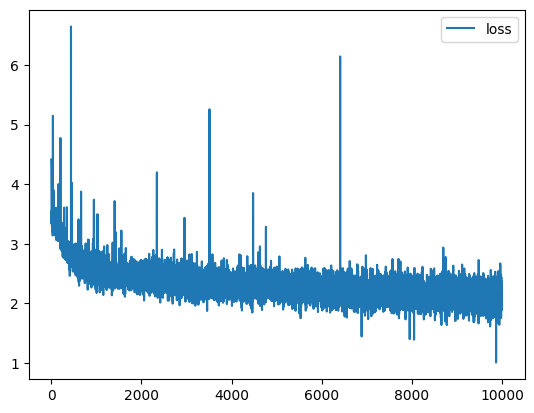

In [ ]:
# Your plot code here
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt


char_rnn = CharRNNCell(rnn_num_units=256)
opt = torch.optim.Adam(char_rnn.parameters())
loss_fn = nn.CrossEntropyLoss()
history = []
n_epoch = 10000

for epoch in range(n_epoch):
  batch_ix = chunk_to_tensor(generate_chunk())
  logit_seq = rnn_loop(char_rnn, batch_ix)
  prediction_logits, actual_next_token = logit_seq[:, :-1], batch_ix[:, 1:]
  loss = loss_fn(
      prediction_logits.reshape(-1, len(tokens)),
      actual_next_token.reshape(-1)
  )
  loss.backward()
  opt.step()
  opt.zero_grad()

  history.append(loss.data.numpy())
  if (epoch+1)%100==0:
        clear_output(True)
        plt.plot(history,label='loss')
        plt.legend()
        plt.show()

assert np.mean(history[:10]) > np.mean(history[-10:]), "RNN didn't converge."

In [ ]:
def generate_sample(char_rnn, seed_phrase='мой дядя', max_length=500, temperature=1.0):
  x_sequence = chunk_to_tensor(seed_phrase)
  hid_state = char_rnn.initial_state(batch_size=1)

  for i in range(len(seed_phrase) - 1):
    hid_state, logits = char_rnn(x_sequence[:, i], hid_state)

    for _ in range(max_length - len(seed_phrase)):
      hid_state, logits = char_rnn(x_sequence[:, -1], hid_state)

      p_next = F.softmax(logits / temperature, dim=-1).squeeze(0).data.numpy()
      next_ix = np.random.choice(len(tokens), p=p_next)
      next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
      x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    # Convert token indices back to text
    generated_text = ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])
    return generated_text

In [ ]:
# An example of generated text.

print(generate_sample(char_rnn, max_length=500, temperature=0.2, seed_phrase='мой дядя самых честных правил '))

мой дядя самых честных правил не всердали всё разновала,
в сем не не пречита в нем недовольной
в нем не пред нем не все друг
мой без после не постили в нем
и встровый верной сердца там,
и встали свете не взоредани,
в дем четать он в дема мила,
призланной сердца том не замет,
в сем не все друзья не всердали
он горовый постором неня в том,
в сел верней в сем не граздуший
вот предний верениве веренья,
стол в нет породенный соновенной
и встали в нем не все в нем нем не всердели,
столи в нем не все д


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

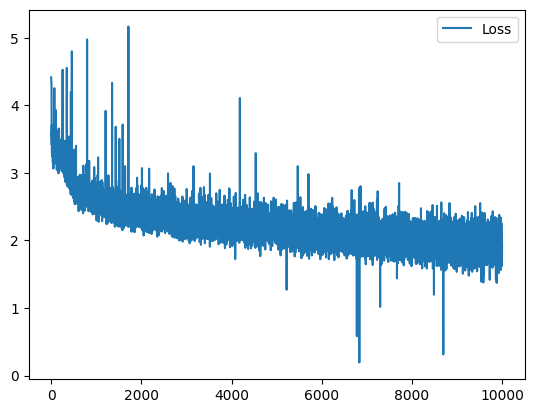

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Вентиль забывания
        self.Wf = nn.Linear(input_size + hidden_size, hidden_size)
        # Вентиль входа
        self.Wi = nn.Linear(input_size + hidden_size, hidden_size)
        # Промежуточное состояние
        self.Wg = nn.Linear(input_size + hidden_size, hidden_size)
        # Вентиль выхода
        self.Wo = nn.Linear(input_size + hidden_size, hidden_size)

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, x, state):
        h, c = state
        # Объединение входа и скрытого состояния
        combined = torch.cat((x, h), dim=1)

        # Вычисление вентилей
        f = self.sigmoid(self.Wf(combined))
        i = self.sigmoid(self.Wi(combined))
        g = self.tanh(self.Wg(combined))
        o = self.sigmoid(self.Wo(combined))

        # Обновление состояния памяти
        c_next = f * c + i * g
        # Новое скрытое состояние
        h_next = o * self.tanh(c_next)

        return h_next, c_next

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.lstm_cell = LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h=None, c=None):
        # One-hot кодирование и транспонирование
        if x.dim() == 1:
          x = x.unsqueeze(0)

        x = F.one_hot(x, num_classes=self.input_size).float()
        x = x.transpose(0, 1)  # (seq_len, batch_size, input_size)

        batch_size = x.size(1)
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        if c is None:
            c = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []

        for t in range(x.size(0)):
            x_t = x[t]  # (batch_size, input_size)
            h, c = self.lstm_cell(x_t, (h, c))
            outputs.append(h)

        # Объединение выходов
        outputs = torch.stack(outputs, dim=0)  # (seq_len, batch_size, hidden_size)
        logits = self.fc(outputs)  # (seq_len, batch_size, output_size)

        return logits, (h, c)


# Инициализация модели
num_tokens = len(tokens)
model = LSTM(num_tokens, 256, num_tokens)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

# Обучение
history = []
n_epoch = 10000

for epoch in range(n_epoch):
    model.zero_grad()
    batch_ix = chunk_to_tensor(generate_chunk())
    prediction, (h, c) = model(batch_ix)

    # Подготовка целевых данных
    targets = batch_ix[:, 1:]  # Задача предсказания следующего символа
    prediction = prediction[:-1]  # Соответствие по длине

    # Вычисление потерь
    loss = loss_fn(prediction.view(-1, num_tokens), targets.view(-1))
    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        clear_output(True)
        plt.plot(history, label='Loss')
        plt.legend()
        plt.show()

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [ ]:
def generate_text(model, start_text="", length=100, temperature=1.0):
    """
    Функция генерации текста на основе обученной LSTM-модели.

    Аргументы:
        model (nn.Module): обученная модель LSTM.
        start_text (str): начальный текст для генерации. Если пустой, используется случайный символ.
        length (int): длина генерируемого текста.
        temperature (float): температура для регулирования случайности предсказаний (0.0 < temperature <= 1.0).
    """
    model.eval()  # Переводим модель в режим оценки
    generated = list(start_text) if start_text else []

    # Инициализация начального состояния
    h = torch.zeros(1, model.hidden_size)
    c = torch.zeros(1, model.hidden_size)

    # Если начальный текст задан, прогоняем его через модель для инициализации состояния
    if generated:
        input_tensor = torch.tensor([token_to_idx[token] for token in generated], dtype=torch.long).unsqueeze(0)
        with torch.no_grad():
            _, (h, c) = model(input_tensor, h, c)
    else:
        # Если начальный текст не задан, выбираем случайный символ
        input_idx = torch.randint(0, len(token_to_idx), (1,)).item()
        input_tensor = torch.tensor([[input_idx]]).to(device)
        generated.append(idx_to_token[input_idx])

    # Генерация текста
    for _ in range(length):
        with torch.no_grad():
            logits, (h, c) = model(input_tensor, h, c)  # Получаем логиты
            logits = logits[-1, :, :] / temperature  # Применяем температуру
            probabilities = F.softmax(logits, dim=-1).data.numpy()  # Преобразуем в вероятности

        # Выбираем следующий токен
        next_idx = np.random.choice(len(probabilities[0]), p=probabilities[0])
        next_token = idx_to_token[next_idx]
        generated.append(next_token)

        # Обновляем входной тензор для следующего шага
        input_tensor = torch.tensor([[next_idx]])

    return ''.join(generated)


In [ ]:
print(generate_text(model, start_text='мой дядя самых честных правил  ', length=500, temperature=0.5))

мой дядя самых честных правил  во холо сторо,
и в толной друзья могорой
за милой нестравал она.



xviii

и след сам онегин в стардно льно
кого он гартенный взрох,
и мосле страстей и блаская,
преденьем себи могой
в семенили на притеренье
он одни сердце в нем страстет
он черто взор вам отдалая,
и свот вы с оставит не возой,
и вос очеровенных порный,
и всег души за милой дало,
и свои полно он ветера
и с ним онегин он гразала,
в скошу преденьем свихой
и бестолчил не раздал.



xlii

«от поляденье северенье,
столом вас от он горо


### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [ ]:
# Saving and loading code here

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch)